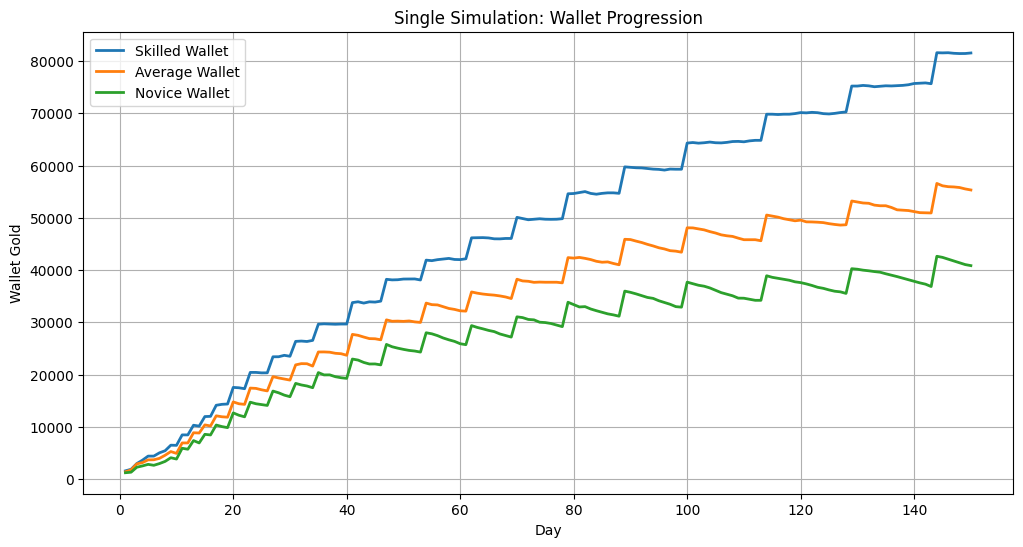

In [1]:
import random
from bisect import bisect_right
import matplotlib.pyplot as plt

# ------------------------
# Game Money & Payout Settings
# ------------------------
# Initial wallet gold for each player
initial_wallet = 1200

# Gold cost to participate in a race
buy_in = 150

# Fixed payouts for top placements (1st, 2nd, 3rd)
payouts_fixed = {1: 180, 2: 120, 3: 100}

# Daily login bonus
daily_login_gold = 150
use_daily_login = True  # Toggle daily login bonus

# Level-up reward toggle
use_levelup_gold = True

# ------------------------
# Simulation Settings
# ------------------------
# Total days to simulate
days = 150

# Function to determine number of races per day (randomly 3 or 4)
def races_today():
    return 3 + (1 if random.random() < 0.5 else 0)

# ------------------------
# Player Types & Win Probabilities
# ------------------------
# Probabilities for placing 1st to 4th for different archetypes
player_archetypes = {
    "Skilled": [0.50, 0.30, 0.15, 0.05],
    "Average": [0.30, 0.25, 0.20, 0.25],
    "Novice":  [0.15, 0.20, 0.25, 0.40],
}

# ------------------------
# Coupled Lobby Performance Settings
# ------------------------
# Mean performance for each archetype in coupled races
coupled_perf_mu = {"Skilled": 1.2, "Average": 0.9, "Novice": 0.6}

# Standard deviation for performance randomness
coupled_perf_sigma = 0.35

# Probability mix of opponents in a lobby
opponent_mix_weights = {"Skilled": 0.25, "Average": 0.50, "Novice": 0.25}

# ------------------------
# XP & Level-Up Settings
# ------------------------
# Average XP earned per game
xp_per_game_avg = 81.7

# Cumulative XP required per level (index = level-1)
cum_xp_by_level = [
    0, 162, 342, 542, 767, 1022, 1312, 1642, 2012, 2427, 2892,
    3412, 3992, 4637, 5352, 6222, 7242, 8422, 9772, 11307,
    13042, 14992, 17172, 19597, 22282, 25242, 28592, 32247,
    36222, 40532, 45192, 50217, 55622, 61422, 67632, 74267,
    81342, 88872, 96902, 105287, 114172, 123572, 133502,
    144002, 155077, 166737, 179002, 191877, 205377, 219502
]
cum_list = [0] + cum_xp_by_level
max_level = 50

# Gold awarded on reaching specific levels
level_to_gold = {
    1:800, 2:300, 3:300, 4:300, 5:1000,
    6:600, 7:600, 8:600, 9:600, 10:1000,
    11:2000, 12:2000, 13:2000, 14:2000, 15:3000,
    16:3000, 17:3000, 18:3000, 19:3000, 20:4000,
    21:4000, 22:4000, 23:4000, 24:4000, 25:5000,
    26:5000, 27:5000, 28:5000, 29:5000, 30:6000,
    31:6000, 32:6000, 33:6000, 34:6000, 35:7000,
    36:7000, 37:7000, 38:7000, 39:7000, 40:8000,
    41:8000, 42:8000, 43:8000, 44:8000, 45:9000,
    46:9000, 47:9000, 48:9000, 49:9000, 50:10000
}

# Function to determine level from cumulative XP
def level_from_xp(xp_total):
    idx = bisect_right(cum_list, xp_total) - 1
    return max(1, min(idx, max_level))

# ------------------------
# Coupled Race Placement Simulation
# ------------------------
def placement_coupled(focal_archetype):
    """
    Simulates a 6-player coupled race and returns the placement of the focal player.
    Returns 1, 2, 3, or "other" if placement is lower than 3rd.
    """
    # Initialize racers list with the focal player
    racers = [("FOCAL", True, focal_archetype)]

    # Randomly select 5 opponents based on weights
    kinds, weights = zip(*opponent_mix_weights.items())
    for _ in range(5):
        a = random.choices(kinds, weights=weights, k=1)[0]
        racers.append(("OPP", False, a))

    # Generate performance scores for each racer
    scores = [random.gauss(coupled_perf_mu[arch if not is_focal else focal_archetype], coupled_perf_sigma)
              for _, is_focal, arch in racers]

    # Rank players based on scores
    order = sorted(range(6), key=lambda i: scores[i], reverse=True)

    # Determine focal player placement
    focal_rank = order.index(0) + 1
    return focal_rank if focal_rank <= 3 else "other"

# ------------------------
# Single Simulation
# ------------------------
# Initialize player state tracking
wallets = {n: initial_wallet for n in player_archetypes}
xp_tot = {n: 0 for n in player_archetypes}
levels = {n: 1 for n in player_archetypes}
daily_wallets = {n: [] for n in player_archetypes}
bankrupt_day = {n: None for n in player_archetypes}

# Simulate each day
for day in range(1, days+1):
    # Apply daily login bonus if enabled
    if use_daily_login:
        for n in player_archetypes:
            wallets[n] += daily_login_gold

    # Run races for the day
    for _ in range(races_today()):
        for n in player_archetypes:
            # Skip race if player cannot afford buy-in
            if wallets[n] < buy_in:
                if bankrupt_day[n] is None:
                    bankrupt_day[n] = day
                continue

            # Deduct buy-in
            wallets[n] -= buy_in

            # Determine placement in coupled race
            place = placement_coupled(n)

            # Apply payout if within top 3
            if place in payouts_fixed:
                wallets[n] += payouts_fixed[place]

            # Update XP and level-up gold
            xp_tot[n] += xp_per_game_avg
            if use_levelup_gold:
                prev = levels[n]
                new = level_from_xp(xp_tot[n])
                if new > prev:
                    wallets[n] += sum(level_to_gold.get(L,0) for L in range(prev+1,new+1))
                    levels[n] = new

    # Record daily wallet balance
    for n in player_archetypes:
        daily_wallets[n].append(wallets[n])

# Mark players who survive all days
for n in player_archetypes:
    if bankrupt_day[n] is None:
        bankrupt_day[n] = days

# ------------------------
# Plot Wallets Over Time
# ------------------------
plt.figure(figsize=(12,6))
days_range = range(1, days+1)
for n in player_archetypes:
    plt.plot(days_range, daily_wallets[n], label=f"{n} Wallet", linewidth=2)
    # Mark bankruptcy day
    if bankrupt_day[n] < days:
        plt.axvline(x=bankrupt_day[n], color='r', linestyle='--', alpha=0.5)
        plt.text(bankrupt_day[n]+1, max(daily_wallets[n])/2, f"{n} bankrupt", color='r')

plt.title("Single Simulation: Wallet Progression")
plt.xlabel("Day")
plt.ylabel("Wallet Gold")
plt.legend()
plt.grid(True)
plt.show()
